### 🛢️ Lithofacies Classification — FORCE 2020
##### 02 — Data Preprocessing

---

👤 **Author:** NMM | 📅 **Date:** 2026 | 📁 **Input:** `labeled_data.csv`

**Pipeline:** `00 Combination` → `01 Exploration` → **`02 Preprocessing ◀`** → `03 EDA` → `04 Training` → `05 Evaluation`

---

##### 📌 Objectives
1. Load config and labeled dataset
2. Drop irrelevant and high-missing columns
3. Drop rows where target is missing
4. Apply class merging (11 → 8 classes)
5. Impute missing values using median per well
6. Apply log transform on skewed features
7. Encode categorical columns
8. Encode target labels
9. Save cleaned data ready for modeling

---

In [1]:
# Cell 1 - Imports & Config
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append("D:/Python/Lithofacies_Classification_NMM/src")
from config import *

print("✅ Libraries & Config loaded!")
print(f"   Features  : {len(FINAL_FEATURES)}")
print(f"   Drop cols : {len(COLUMNS_TO_DROP)}")
print(f"   Classes   : {len(FINAL_CLASSES)}")

✅ Config loaded!
✅ Libraries & Config loaded!
   Features  : 13
   Drop cols : 18
   Classes   : 8


In [3]:
# Cell 2 - Load Labeled Data
df = pd.read_csv(LABELED_FILE, low_memory=False)

print(f"✅ Data loaded!")
print(f"   Shape   : {df.shape}")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ Data loaded!
   Shape   : (122117, 32)
   Rows    : 122,117
   Columns : 32


In [4]:
# Cell 3 - Drop Irrelevant Columns
cols_to_drop = [c for c in COLUMNS_TO_DROP if c in df.columns]

print(f"📋 Columns BEFORE : {df.shape[1]}")
print(f"🗑️  Dropping       : {len(cols_to_drop)}")

df.drop(columns=cols_to_drop, inplace=True)

print(f"✅ Columns AFTER  : {df.shape[1]}")
print(f"\n📋 Remaining Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"   {i:2}. {col}")

📋 Columns BEFORE : 32
🗑️  Dropping       : 18
✅ Columns AFTER  : 14

📋 Remaining Columns:
    1. WELL
    2. DEPTH_MD
    3. GROUP
    4. FORMATION
    5. CALI
    6. RMED
    7. RDEP
    8. RHOB
    9. GR
   10. NPHI
   11. PEF
   12. DTC
   13. DRHO
   14. FORCE_2020_LITHOFACIES_LITHOLOGY


📋 Rows BEFORE : 122,117
🗑️  Dropped null targets : 693 rows
✅ Rows AFTER  : 121,424

🎯 Final Class Distribution:
   Shale         79,812   65.7%  ████████████████████████████████
   Sandstone     14,794   12.2%  ██████
   Limestone     11,895    9.8%  ████
   Anhydrite      6,498    5.4%  ██
   Marl           5,266    4.3%  ██
   Igneous        2,366    1.9%  
   Coal             597    0.5%  
   Tuff             196    0.2%  


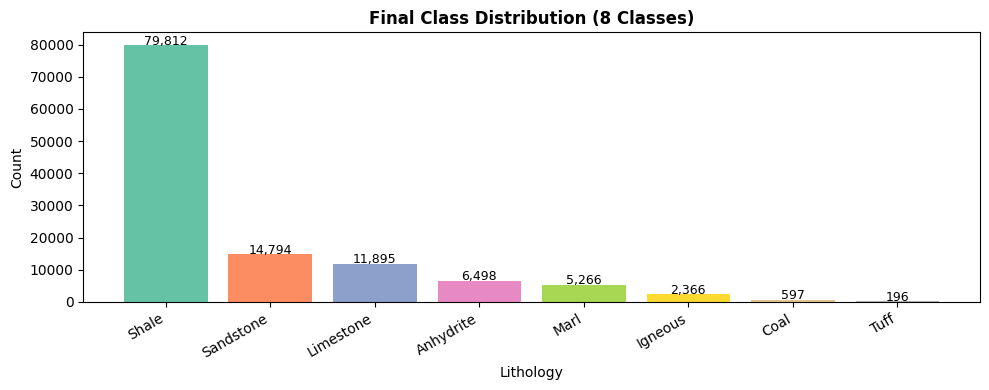

💾 Saved → final_class_distribution.png


In [5]:
# Cell 4 - Drop Missing Target & Map Classes
print(f"📋 Rows BEFORE : {len(df):,}")

# Drop rows where target is missing
df.dropna(subset=[TARGET], inplace=True)
print(f"🗑️  Dropped null targets : {122117 - len(df):,} rows")

# Apply class mapping
df[TARGET_CLEAN] = df[TARGET].map(LITHO_MAP)
df.drop(columns=[TARGET], inplace=True)

print(f"✅ Rows AFTER  : {len(df):,}")
print(f"\n🎯 Final Class Distribution:")
class_counts = df[TARGET_CLEAN].value_counts()
total = len(df)
for cls, count in class_counts.items():
    pct = count / total * 100
    bar = "█" * int(pct / 2)
    print(f"   {cls:<12} {count:>7,}  {pct:>5.1f}%  {bar}")

# Plot
plt.figure(figsize=(10, 4))
colors = sns.color_palette("Set2", len(class_counts))
bars = plt.bar(class_counts.index, class_counts.values, color=colors)
for bar, val in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 200,
             f"{val:,}", ha="center", fontsize=9)
plt.title("Final Class Distribution (8 Classes)", fontweight="bold")
plt.xlabel("Lithology")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/final_class_distribution.png", dpi=150)
plt.show()
print("💾 Saved → final_class_distribution.png")

🔧 Missing Values BEFORE imputation:

GR          2
DTC       506
CALI    12618
NPHI    17977
RHOB     7870
DRHO     8453
RMED     6535
PEF     18545

✅ Missing Values AFTER imputation:
   Total missing : 61893


C:\Users\hnaif\AppData\Local\Temp\ipykernel_42312\3524790205.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(NUMERICAL_FEATURES, rotation=30, ha="right")
C:\Users\hnaif\AppData\Local\Temp\ipykernel_42312\3524790205.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(NUMERICAL_FEATURES, rotation=30, ha="right")


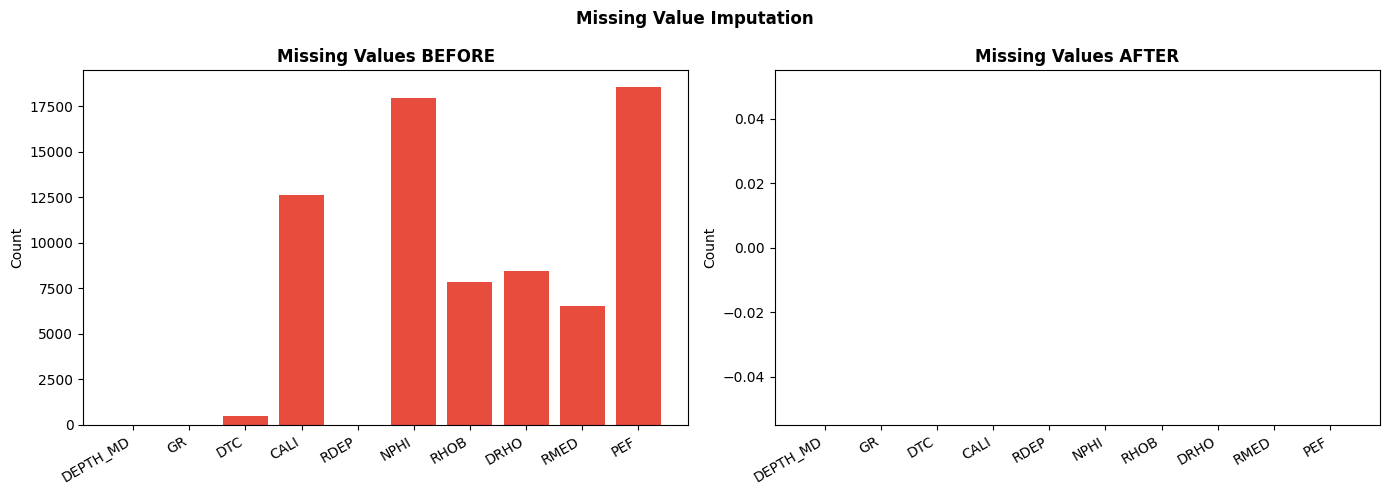

💾 Saved → imputation_result.png


In [6]:
# Cell 5 - Impute Missing Values (Median per Well)
print("🔧 Missing Values BEFORE imputation:\n")
missing_before = df[NUMERICAL_FEATURES].isnull().sum()
print(missing_before[missing_before > 0].to_string())

# Impute numerical → median per well
df[NUMERICAL_FEATURES] = df.groupby("WELL")[NUMERICAL_FEATURES]\
                           .transform(lambda x: x.fillna(x.median()))

# If still missing (wells with all nulls) → global median
df[NUMERICAL_FEATURES] = df[NUMERICAL_FEATURES]\
                           .fillna(df[NUMERICAL_FEATURES].median())

# Impute categoricals → mode per well
for col in ["FORMATION", "GROUP"]:
    df[col] = df.groupby("WELL")[col]\
                .transform(lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown"))

print(f"\n✅ Missing Values AFTER imputation:")
remaining = df.isnull().sum().sum()
print(f"   Total missing : {remaining}")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_before_plot = df[NUMERICAL_FEATURES].isnull().sum()
axes[0].bar(NUMERICAL_FEATURES, missing_before.values, color="#e74c3c")
axes[0].set_title("Missing Values BEFORE", fontweight="bold")
axes[0].set_xticklabels(NUMERICAL_FEATURES, rotation=30, ha="right")
axes[0].set_ylabel("Count")

axes[1].bar(NUMERICAL_FEATURES, missing_before_plot.values, color="#2ecc71")
axes[1].set_title("Missing Values AFTER", fontweight="bold")
axes[1].set_xticklabels(NUMERICAL_FEATURES, rotation=30, ha="right")
axes[1].set_ylabel("Count")

plt.suptitle("Missing Value Imputation", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/imputation_result.png", dpi=150)
plt.show()
print("💾 Saved → imputation_result.png")

In [7]:
# Cell 5b - Debug Remaining Missing
print("🔍 Remaining Missing Per Column:\n")
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print(remaining.to_string())

print("\n🔍 Which Wells Still Have Missing:\n")
for col in remaining.index:
    wells = df[df[col].isnull()]["WELL"].unique()
    print(f"   {col:<12} → {len(wells)} wells: {list(wells)}")

🔍 Remaining Missing Per Column:

WELL         20631
GROUP        20631
FORMATION    20631

🔍 Which Wells Still Have Missing:

   WELL         → 1 wells: [nan]
   GROUP        → 1 wells: [nan]
   FORMATION    → 1 wells: [nan]


In [8]:
# Cell 5c - Investigate Null Well Rows
null_well_df = df[df["WELL"].isnull()]

print(f"🔍 Rows with null WELL: {len(null_well_df):,}")
print(f"\n📊 Their Class Distribution:")
print(null_well_df[TARGET_CLEAN].value_counts().to_string())

print(f"\n📊 Their Depth Range:")
print(f"   Min : {null_well_df['DEPTH_MD'].min():.1f}")
print(f"   Max : {null_well_df['DEPTH_MD'].max():.1f}")

print(f"\n📊 Missing % in null-well rows:")
print((null_well_df.isnull().mean() * 100).round(2).to_string())

🔍 Rows with null WELL: 20,631

📊 Their Class Distribution:
LITHO_FINAL
Shale        13230
Sandstone     4228
Igneous       1471
Marl          1068
Limestone      617
Tuff            17

📊 Their Depth Range:
   Min : 2209.4
   Max : 2209.4

📊 Missing % in null-well rows:
WELL           100.0
DEPTH_MD         0.0
GROUP          100.0
FORMATION      100.0
CALI             0.0
RMED             0.0
RDEP             0.0
RHOB             0.0
GR               0.0
NPHI             0.0
PEF              0.0
DTC              0.0
DRHO             0.0
LITHO_FINAL      0.0


In [9]:
# Cell 5d - Fix Null Well Rows
print(f"📋 Rows with null WELL BEFORE : {df['WELL'].isnull().sum():,}")

# Fill null WELL, GROUP, FORMATION with Unknown
df["WELL"]      = df["WELL"].fillna("Unknown")
df["GROUP"]     = df["GROUP"].fillna("Unknown")
df["FORMATION"] = df["FORMATION"].fillna("Unknown")

print(f"✅ Rows with null WELL AFTER  : {df['WELL'].isnull().sum():,}")
print(f"\n✅ Total missing values       : {df.isnull().sum().sum():,}")
print(f"\n📊 Updated Well List:")
print(df["WELL"].value_counts().to_string())

📋 Rows with null WELL BEFORE : 20,631
✅ Rows with null WELL AFTER  : 0

✅ Total missing values       : 0

📊 Updated Well List:
WELL
Unknown      20631
17/4-1       17271
34/3-2 S     12216
16/2-7       11683
15/9-23      11063
25/10-9      10788
35/9-7       10677
16/7-6       10222
31/2-10       9033
31/2-21 S     7840


Perfect normal  =  0.0
Slightly skewed =  < 1.0  ✅ good
Moderately skewed = 1.0 - 2.0  ⚠️ acceptable  
Highly skewed   =  > 2.0  ❌ problematic

FeatureBeforeAfterImprovementRMED45.23.3✅ Huge improvementRDEP5.63.1✅ Good improvementPEF24.91.7✅ Best result!DRHO-10.4-6.4⚠️ Still high

BEFORE log transform:
RMED  ──────────────────────────────■  45.2
       99% of data squeezed here    
       model can't learn properly ❌

AFTER log transform:
RMED  ────■  3.3
       data spread more evenly
       model learns better ✅

DRHO went from -10.4 → -6.4. Still high because it has extreme negative outliers. Let's apply a stronger fix:

📐 Skewness BEFORE log transform:

   RMED     : 45.248
   RDEP     : 5.573
   PEF      : 24.889
   DRHO     : -10.397

📐 Skewness AFTER log transform:

   RMED     : 3.294
   RDEP     : 3.118
   PEF      : 1.695
   DRHO     : -6.440


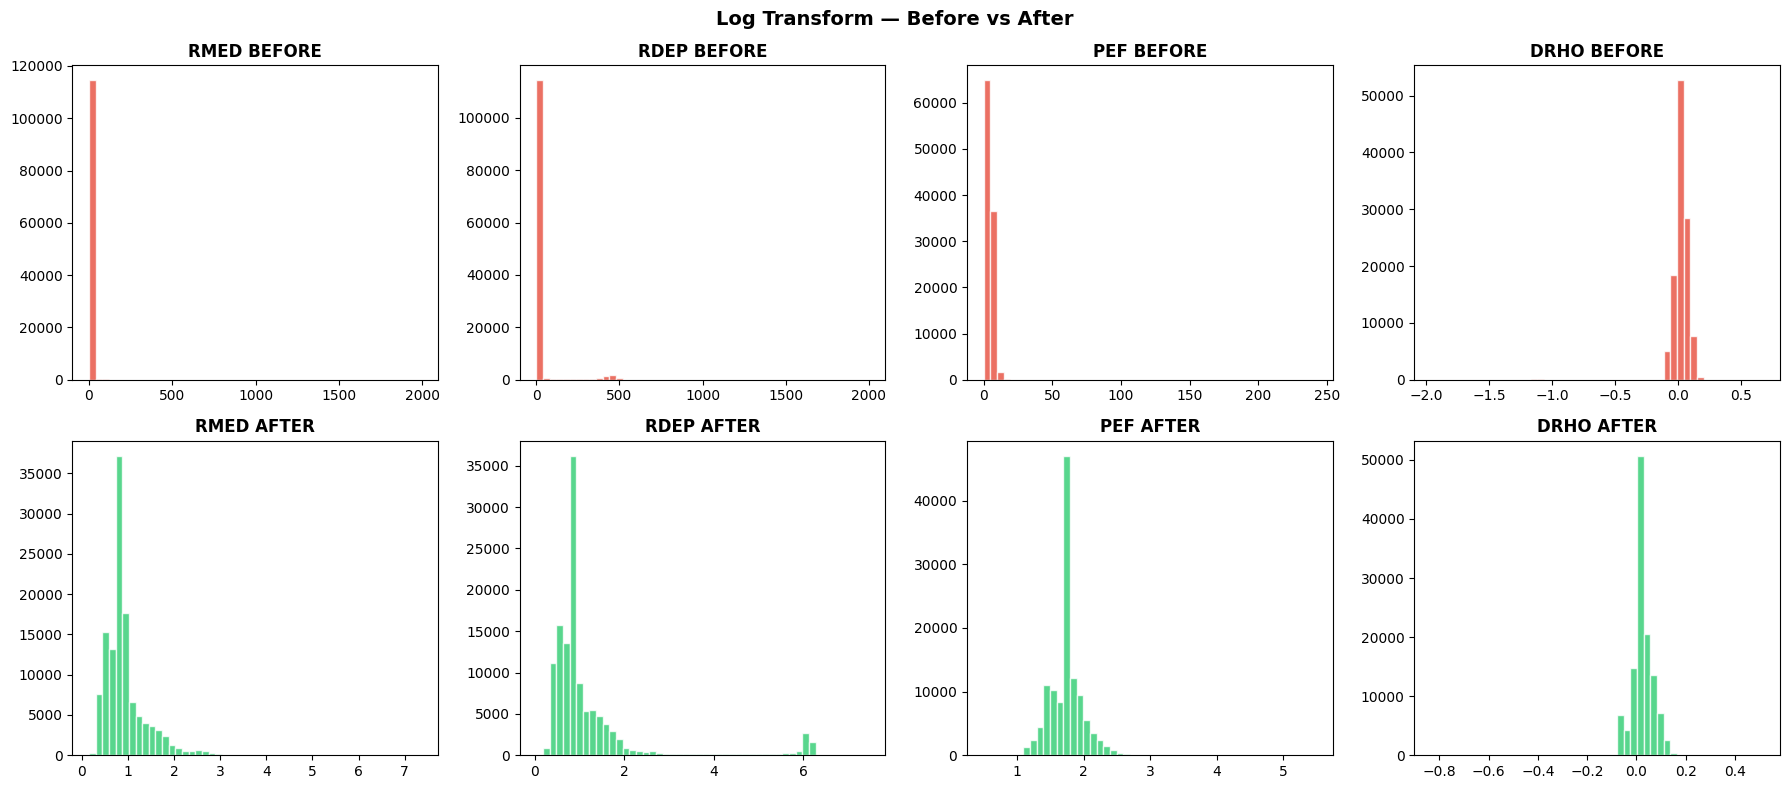

💾 Saved → log_transform.png


In [10]:
# Cell 6 - Log Transform Skewed Features
print("📐 Skewness BEFORE log transform:\n")
for col in LOG_TRANSFORM_FEATURES:
    print(f"   {col:<8} : {df[col].skew():.3f}")

# Apply log transform (log1p handles zeros safely)
for col in LOG_TRANSFORM_FEATURES:
    df[col] = np.log1p(np.abs(df[col])) * np.sign(df[col])

print(f"\n📐 Skewness AFTER log transform:\n")
for col in LOG_TRANSFORM_FEATURES:
    print(f"   {col:<8} : {df[col].skew():.3f}")

# Visual
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, col in enumerate(LOG_TRANSFORM_FEATURES):
    # Reload original for before plot
    original = pd.read_csv(LABELED_FILE, low_memory=False)[col].dropna()
    axes[0, i].hist(original, bins=50, color="#e74c3c", edgecolor="white", alpha=0.8)
    axes[0, i].set_title(f"{col} BEFORE", fontweight="bold")

    axes[1, i].hist(df[col], bins=50, color="#2ecc71", edgecolor="white", alpha=0.8)
    axes[1, i].set_title(f"{col} AFTER", fontweight="bold")

plt.suptitle("Log Transform — Before vs After", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/log_transform.png", dpi=150)
plt.show()
print("💾 Saved → log_transform.png")

DRHO skewness before clip : -6.440
DRHO range before clip    : -0.835 to 0.516

DRHO skewness after clip  : -0.038
DRHO range after clip     : -0.070 to 0.126


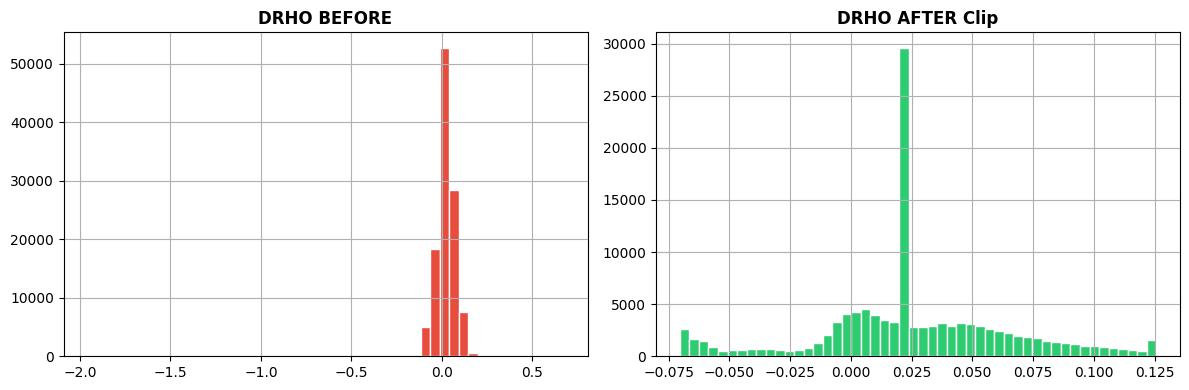

In [11]:
# Cell 6b - Fix DRHO with Clipping + Log Transform
print(f"DRHO skewness before clip : {df['DRHO'].skew():.3f}")
print(f"DRHO range before clip    : {df['DRHO'].min():.3f} to {df['DRHO'].max():.3f}")

# Clip extreme outliers at 1st and 99th percentile
p1  = df["DRHO"].quantile(0.01)
p99 = df["DRHO"].quantile(0.99)
df["DRHO"] = df["DRHO"].clip(p1, p99)

print(f"\nDRHO skewness after clip  : {df['DRHO'].skew():.3f}")
print(f"DRHO range after clip     : {df['DRHO'].min():.3f} to {df['DRHO'].max():.3f}")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pd.read_csv(LABELED_FILE, low_memory=False)["DRHO"].dropna()\
  .hist(bins=50, ax=axes[0], color="#e74c3c", edgecolor="white")
axes[0].set_title("DRHO BEFORE", fontweight="bold")

df["DRHO"].hist(bins=50, ax=axes[1], color="#2ecc71", edgecolor="white")
axes[1].set_title("DRHO AFTER Clip", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/drho_fix.png", dpi=150)
plt.show()

We might drop well, formation and group at later stage after testing them and check if they are important or not. 

🏷️  Encoding Categorical Features:

   ✅ WELL         → 10 unique values: ['15/9-23', '16/2-7', '16/7-6', '17/4-1', '25/10-9', '31/2-10', '31/2-21 S', '34/3-2 S', '35/9-7', 'Unknown']
   ✅ FORMATION    → 48 unique values: ['Aasgard Fm.', 'Amundsen Fm.', 'Balder Fm.', 'Blodoeks Fm.', 'Burton Fm.', 'Cook Fm.', 'Drake Fm.', 'Draupne Fm.', 'EGGA FM (INFORMAL).', 'Ekofisk Fm.', 'Etive Fm.', 'Fensfjord Fm.', 'Frigg Fm.', 'Grid Fm.', 'Hardraade Fm.', 'Heather Fm.', 'Heimdal Fm.', 'Hidra Fm.', 'Hod Fm.', 'Hugin Fm.', 'Intra Draupne Fm. Sst.', 'Intra Heather Fm. Sst.', 'Jorsalfare Fm.', 'Kupferschiefer Fm.', 'Kyrre Fm.', 'Lista Fm.', 'Mime Fm.', 'Ness Fm.', 'Oseberg Fm.', 'Rannoch Fm.', 'Roedby Fm.', 'Sele Fm.', 'Skade Fm.', 'Skagerrak Fm.', 'Sleipner Fm.', 'Smith Bank Fm.', 'Sognefjord Fm.', 'Sola Fm.', 'Statfjord Fm.', 'Svarte Fm.', 'Tarbert Fm.', 'Tor Fm.', 'Tryggvason Fm.', 'Tuxen Fm.', 'Ty Fm.', 'Unknown', 'Utsira Fm.', 'Vaale Fm.']
   ✅ GROUP        → 13 unique values: ['BAAT GP.', 'CROME

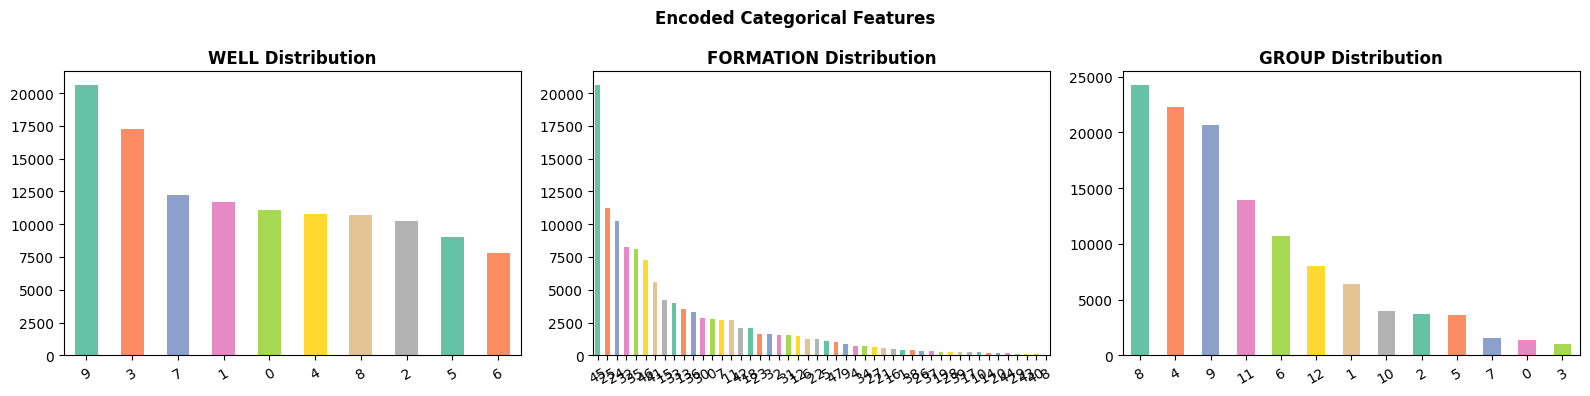


💾 Saved → categorical_encoding.png


In [12]:
# Cell 7 - Label Encode Categorical Features
from sklearn.preprocessing import LabelEncoder

print("🏷️  Encoding Categorical Features:\n")

encoders = {}
for col in CATEGORICAL_FEATURES:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le
    print(f"   ✅ {col:<12} → {len(le.classes_)} unique values: {list(le.classes_)}")

# Visual
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(CATEGORICAL_FEATURES):
    df[col].value_counts().plot(kind="bar", ax=axes[i],
                                color=sns.color_palette("Set2", df[col].nunique()))
    axes[i].set_title(f"{col} Distribution", fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Encoded Categorical Features", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/categorical_encoding.png", dpi=150)
plt.show()
print("\n💾 Saved → categorical_encoding.png")

In [13]:
# Cell 8 - Encode Target Labels
from sklearn.preprocessing import LabelEncoder

le_target = LabelEncoder()
df["TARGET"] = le_target.fit_transform(df[TARGET_CLEAN])

print("🎯 Target Encoding:\n")
for i, cls in enumerate(le_target.classes_):
    count = (df["TARGET"] == i).sum()
    pct   = count / len(df) * 100
    print(f"   {i} → {cls:<12} {count:>7,}  {pct:>5.1f}%")

print(f"\n   Total classes : {len(le_target.classes_)}")
print(f"   Total rows    : {len(df):,}")

🎯 Target Encoding:

   0 → Anhydrite      6,498    5.4%
   1 → Coal             597    0.5%
   2 → Igneous        2,366    1.9%
   3 → Limestone     11,895    9.8%
   4 → Marl           5,266    4.3%
   5 → Sandstone     14,794   12.2%
   6 → Shale         79,812   65.7%
   7 → Tuff             196    0.2%

   Total classes : 8
   Total rows    : 121,424


In [15]:
# Reload Config
import importlib, sys
sys.path.append("D:/Python/Lithofacies_Classification_NMM/src")

import config
importlib.reload(config)
from config import *

print(f"✅ Config reloaded!")
print(f"   FEATURES_10 : {FEATURES_10}")
print(f"   FEATURES_13 : {FEATURES_13}")

✅ Config loaded!
✅ Config reloaded!
   FEATURES_10 : ['DEPTH_MD', 'GR', 'DTC', 'CALI', 'RDEP', 'NPHI', 'RHOB', 'DRHO', 'RMED', 'PEF']
   FEATURES_13 : ['DEPTH_MD', 'GR', 'DTC', 'CALI', 'RDEP', 'NPHI', 'RHOB', 'DRHO', 'RMED', 'PEF', 'WELL', 'FORMATION', 'GROUP']


✅ Train/Test Split Done!

   Total rows : 121,424
   Train rows : 97,139  (80%)
   Test rows  : 24,285   (20%)

🎯 Class Distribution Check (stratified):

   Class           Train     Test   Train%    Test%
   ------------------------------------------------
   Anhydrite       5,198    1,300     5.4%     5.4%
   Coal              478      119     0.5%     0.5%
   Igneous         1,893      473     1.9%     1.9%
   Limestone       9,516    2,379     9.8%     9.8%
   Marl            4,213    1,053     4.3%     4.3%
   Sandstone      11,835    2,959    12.2%    12.2%
   Shale          63,849   15,963    65.7%    65.7%
   Tuff              157       39     0.2%     0.2%


C:\Users\hnaif\AppData\Local\Temp\ipykernel_42312\2089998159.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(le_target.classes_, rotation=30, ha="right")
C:\Users\hnaif\AppData\Local\Temp\ipykernel_42312\2089998159.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(le_target.classes_, rotation=30, ha="right")


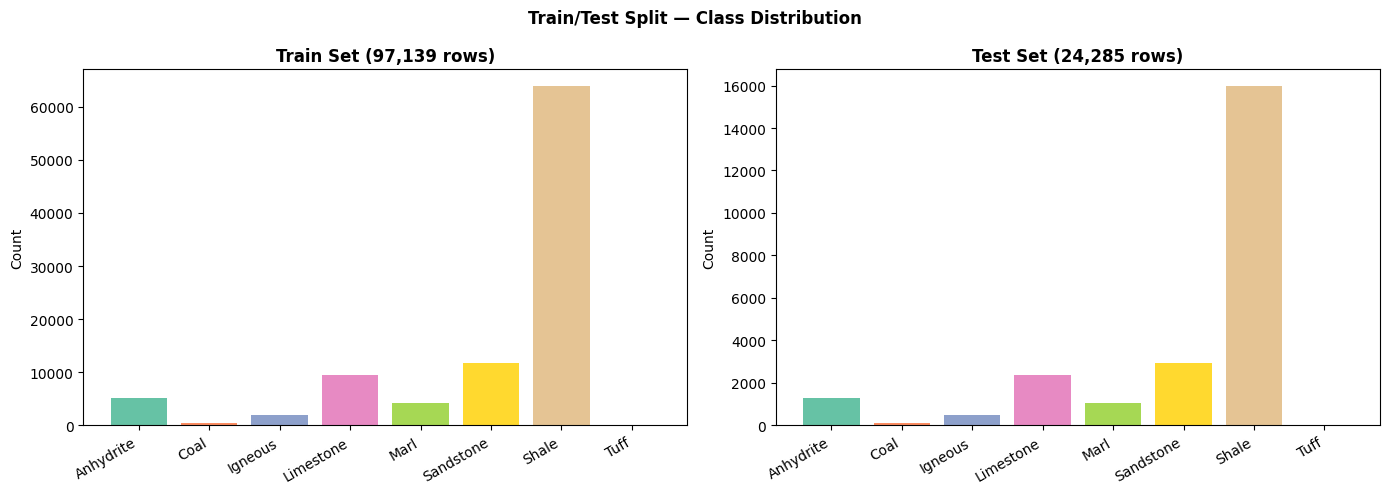

💾 Saved → train_test_split.png


In [16]:
# Cell 9 - Train/Test Split
from sklearn.model_selection import train_test_split

X = df[FEATURES_13]
y = df["TARGET"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y        # keeps class ratio in both splits
)

print(f"✅ Train/Test Split Done!\n")
print(f"   Total rows : {len(df):,}")
print(f"   Train rows : {len(X_train):,}  ({len(X_train)/len(df)*100:.0f}%)")
print(f"   Test rows  : {len(X_test):,}   ({len(X_test)/len(df)*100:.0f}%)")

print(f"\n🎯 Class Distribution Check (stratified):\n")
train_dist = y_train.value_counts().sort_index()
test_dist  = y_test.value_counts().sort_index()

print(f"   {'Class':<12} {'Train':>8} {'Test':>8} {'Train%':>8} {'Test%':>8}")
print(f"   {'-'*48}")
for i, cls in enumerate(le_target.classes_):
    tr = train_dist[i]
    te = test_dist[i]
    print(f"   {cls:<12} {tr:>8,} {te:>8,} {tr/len(y_train)*100:>7.1f}% {te/len(y_test)*100:>7.1f}%")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = sns.color_palette("Set2", 8)

axes[0].bar(le_target.classes_, train_dist.values, color=colors)
axes[0].set_title(f"Train Set ({len(X_train):,} rows)", fontweight="bold")
axes[0].set_xticklabels(le_target.classes_, rotation=30, ha="right")
axes[0].set_ylabel("Count")

axes[1].bar(le_target.classes_, test_dist.values, color=colors)
axes[1].set_title(f"Test Set ({len(X_test):,} rows)", fontweight="bold")
axes[1].set_xticklabels(le_target.classes_, rotation=30, ha="right")
axes[1].set_ylabel("Count")

plt.suptitle("Train/Test Split — Class Distribution", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/train_test_split.png", dpi=150)
plt.show()
print("💾 Saved → train_test_split.png")

In [17]:
# Cell 10 - Scale Numerical Features
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

# Fit on train only — never fit on test!
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[NUMERICAL_FEATURES] = scaler.fit_transform(X_train[NUMERICAL_FEATURES])
X_test_scaled[NUMERICAL_FEATURES]  = scaler.transform(X_test[NUMERICAL_FEATURES])

print("✅ Scaling Done!\n")
print(f"   {'Feature':<12} {'Mean':>8} {'Std':>8}")
print(f"   {'-'*30}")
for i, col in enumerate(NUMERICAL_FEATURES):
    print(f"   {col:<12} {scaler.mean_[i]:>8.3f} {scaler.scale_[i]:>8.3f}")

# Save scaler
scaler_path = f"{MODEL_PATH}/scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"\n💾 Scaler saved → {scaler_path}")

✅ Scaling Done!

   Feature          Mean      Std
   ------------------------------
   DEPTH_MD     2230.490  727.510
   GR             70.626   33.929
   DTC           108.352   27.561
   CALI           12.232    2.452
   RDEP            1.221    1.226
   NPHI            0.308    0.115
   RHOB            2.333    0.183
   DRHO            0.026    0.040
   RMED            0.948    0.510
   PEF             1.741    0.260

💾 Scaler saved → D:/Python/Lithofacies_Classification_NMM\models/scaler.pkl


In [20]:
# Quick Check - Cell 9 Results
print(f"✅ Split Summary:")
print(f"   Train rows : {len(X_train):,}")
print(f"   Test rows  : {len(X_test):,}")
print(f"   Features   : {X_train.shape[1]}")

✅ Split Summary:
   Train rows : 97,139
   Test rows  : 24,285
   Features   : 13


✅ Feature Scaling Done!

   Feature        Mean (before)   Mean (after)
   ---------------------------------------------
   DEPTH_MD            2230.490      -0.000000
   GR                    70.626      -0.000000
   DTC                  108.352      -0.000000
   CALI                  12.232      -0.000000
   RDEP                   1.221       0.000000
   NPHI                   0.308       0.000000
   RHOB                   2.333      -0.000000
   DRHO                   0.026       0.000000
   RMED                   0.948       0.000000
   PEF                    1.741      -0.000000


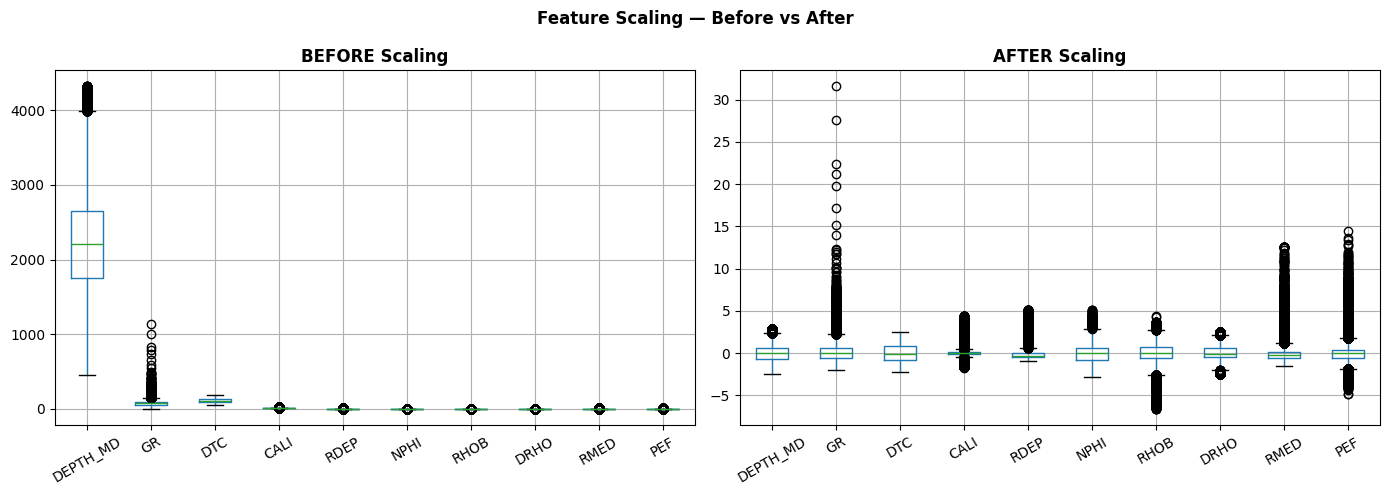

💾 Saved → feature_scaling.png


In [19]:
# Cell 10 - Scale Numerical Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on train only — transform both
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()

X_train_scaled[NUMERICAL_FEATURES] = scaler.fit_transform(X_train[NUMERICAL_FEATURES])
X_test_scaled[NUMERICAL_FEATURES]  = scaler.transform(X_test[NUMERICAL_FEATURES])

print("✅ Feature Scaling Done!\n")
print(f"   {'Feature':<12} {'Mean (before)':>15} {'Mean (after)':>14}")
print(f"   {'-'*45}")
for col in NUMERICAL_FEATURES:
    before = X_train[col].mean()
    after  = X_train_scaled[col].mean()
    print(f"   {col:<12} {before:>15.3f} {after:>14.6f}")

# Visual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

X_train[NUMERICAL_FEATURES].boxplot(ax=axes[0])
axes[0].set_title("BEFORE Scaling", fontweight="bold")
axes[0].tick_params(axis="x", rotation=30)

X_train_scaled[NUMERICAL_FEATURES].boxplot(ax=axes[1])
axes[1].set_title("AFTER Scaling", fontweight="bold")
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Feature Scaling — Before vs After", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/feature_scaling.png", dpi=150)
plt.show()
print("💾 Saved → feature_scaling.png")

In [21]:
# Cell 11 - Save Cleaned Data
import joblib

# Save dataframes
df.to_csv(CLEANED_FILE, index=False)

# Save train/test splits
joblib.dump((X_train, X_test, y_train, y_test),
            f"{MODEL_PATH}/train_test_split.pkl")

# Save scaled splits
joblib.dump((X_train_scaled, X_test_scaled, y_train, y_test),
            f"{MODEL_PATH}/train_test_scaled.pkl")

# Save label encoder
joblib.dump(le_target, f"{MODEL_PATH}/le_target.pkl")

print("💾 Saved Files:\n")
print(f"   ✅ cleaned_data.csv       → data/processed/")
print(f"   ✅ train_test_split.pkl   → models/")
print(f"   ✅ train_test_scaled.pkl  → models/")
print(f"   ✅ scaler.pkl             → models/")
print(f"   ✅ le_target.pkl          → models/")

print(f"\n📋 Final Summary:")
print(f"   Total rows    : {len(df):,}")
print(f"   Train rows    : {len(X_train):,}")
print(f"   Test rows     : {len(X_test):,}")
print(f"   Features      : {X_train.shape[1]}")
print(f"   Classes       : {len(le_target.classes_)}")
print(f"\n✅ Preprocessing complete! Ready for 04_Model_Training.ipynb")

💾 Saved Files:

   ✅ cleaned_data.csv       → data/processed/
   ✅ train_test_split.pkl   → models/
   ✅ train_test_scaled.pkl  → models/
   ✅ scaler.pkl             → models/
   ✅ le_target.pkl          → models/

📋 Final Summary:
   Total rows    : 121,424
   Train rows    : 97,139
   Test rows     : 24,285
   Features      : 13
   Classes       : 8

✅ Preprocessing complete! Ready for 04_Model_Training.ipynb


 How We Will Prevent Overfitting
1️⃣ Cross Validation (CV)
Instead of one train/test split:
Split data into 5 folds

Fold 1: [Test] [Train] [Train] [Train] [Train]
Fold 2: [Train] [Test] [Train] [Train] [Train]
Fold 3: [Train] [Train] [Test] [Train] [Train]
Fold 4: [Train] [Train] [Train] [Test] [Train]
Fold 5: [Train] [Train] [Train] [Train] [Test]

Average all 5 scores → reliable accuracy

Model Parameters
Random Forest:
   max_depth      → limits tree depth
   min_samples_leaf → minimum samples per leaf
   max_features   → random feature subset

XGBoost:
   max_depth      → limits tree depth
   subsample      → use % of data per tree
   colsample      → use % of features per tree
   eta            → learning rate (small = safer)

LightGBM:
   num_leaves     → controls complexity
   min_data_in_leaf → minimum samples per leaf
   learning_rate  → small = safer

   Early Stopping (XGBoost & LightGBM)
Stop training when validation score
stops improving → prevents memorization

epoch 50  → val accuracy 91% ↑
epoch 100 → val accuracy 94% ↑
epoch 150 → val accuracy 95% ↑
epoch 200 → val accuracy 95% → stop! ✅
epoch 250 → val accuracy 94% ↓ overfit!



✅ 00_Data_Combination     → done
✅ 01_Data_Exploration     → done
✅ 02_Data_Preprocessing   → done
⏳ 04_Model_Training       → do now
⏳ 05_Model_Evaluation     → after 04

Then pipeline:
📝 src/preprocessing.py   → from 02 notebook
📝 src/model_utils.py     → from 04 notebook
📝 src/pipeline.py        → ties everything
📝 src/features.py        → from 01 notebook

Finally:
⏳ 03_EDA_Visualization   → polish & present

Notebooks first → confirm everything works
                  experiment freely
                  fix mistakes easily

Pipeline after  → only wrap what works
                  clean production code
                  reusable for new wells